In [4]:
!pip install xgboost



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import re


In [8]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

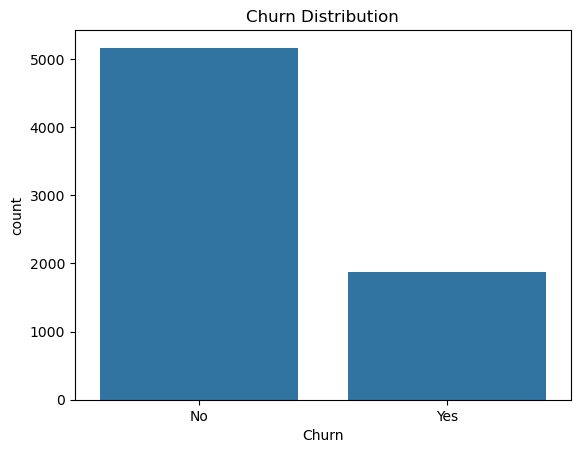

In [11]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

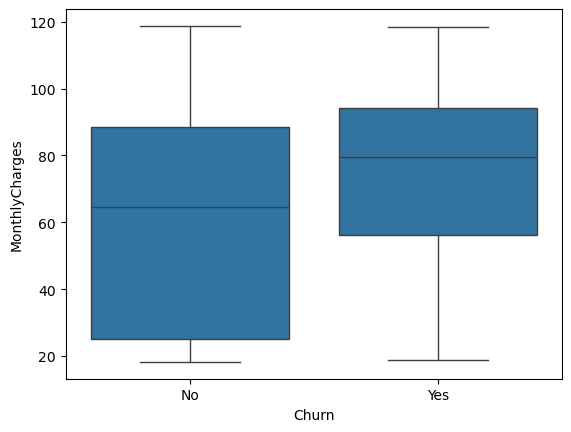

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

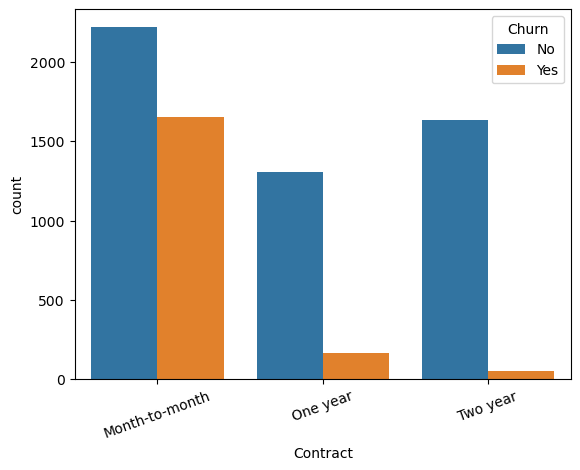

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.show()

In [14]:
logs = """
2026-02-01 10:30:45 | UserID:101 | Network:4G | Status:Drop
2026-02-01 11:15:20 | UserID:102 | Network:5G | Status:Active
"""

In [15]:
pattern = r'(?P<time>[\d\-: ]+) \| UserID:(?P<user>\d+) \| Network:(?P<net>\w+) \| Status:(?P<status>\w+)'

parsed_logs = [re.search(pattern, line).groupdict() for line in logs.strip().split('\n')]
log_df = pd.DataFrame(parsed_logs)

log_df

,time,user,net,status
0,2026-02-01 10:30:45,101,4G,Drop
1,2026-02-01 11:15:20,102,5G,Active


In [16]:
df.drop('customerID', axis=1, inplace=True)

In [17]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.7356076759061834
ROC-AUC: 0.8322069565307423
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.74      0.75      1407



In [40]:
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [41]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Youden's J statistic
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.43567628


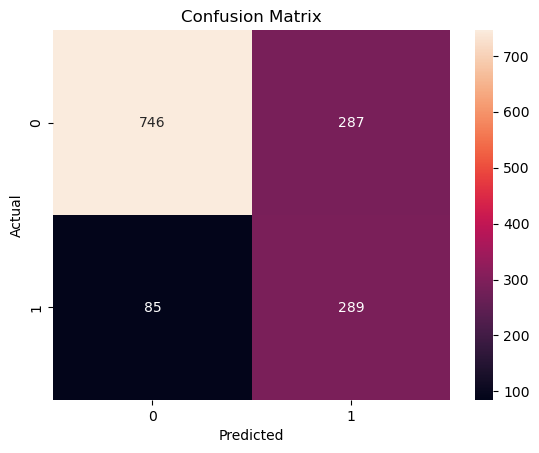

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [46]:
model = pipeline.named_steps['model']

import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

Contract           0.406422
OnlineSecurity     0.110388
InternetService    0.094403
TechSupport        0.077676
StreamingMovies    0.033599
tenure             0.033032
MonthlyCharges     0.025124
StreamingTV        0.022515
OnlineBackup       0.021183
PaymentMethod      0.021012
dtype: float32


In [47]:
X_test_copy = X_test.copy()
X_test_copy["Churn_Probability"] = y_prob

# Show top 10 highest churn risk customers
X_test_copy.sort_values(by="Churn_Probability", ascending=False).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability
1976,1,1,0,0,1,1,2,1,0,0,0,0,2,2,0,1,2,93.55,93.55,0.976084
2577,0,0,0,0,1,1,2,1,0,0,0,0,2,2,0,1,2,94.60,94.60,0.973365
1600,1,1,0,0,1,1,2,1,0,0,2,0,2,0,0,1,2,88.80,88.80,0.967676
2753,0,0,0,0,1,1,2,1,0,0,0,0,2,2,0,0,3,95.65,95.65,0.967087
5186,0,1,0,0,1,0,1,0,0,0,0,0,2,0,0,1,2,36.45,36.45,0.964243
5783,0,1,0,0,1,1,0,1,0,0,0,0,2,2,0,1,2,89.30,89.30,0.964163
6748,0,1,0,0,1,1,0,1,0,0,2,0,0,2,0,1,2,85.00,85.00,0.963253
997,0,1,0,0,4,1,2,1,0,0,0,0,2,2,0,1,2,94.30,424.45,0.962747
2727,1,0,0,0,5,1,2,1,0,0,0,0,2,2,0,1,0,94.85,462.80,0.961677
6473,0,0,0,0,1,1,0,1,0,0,2,0,2,2,0,0,2,94.40,94.40,0.960575


In [48]:
import joblib
joblib.dump(pipeline, "churn_model.pkl")

['churn_model.pkl']

In [49]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_prob >= best_threshold).astype(int)

In [50]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

Accuracy: 0.7221037668798863
              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1033
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.72      0.74      1407



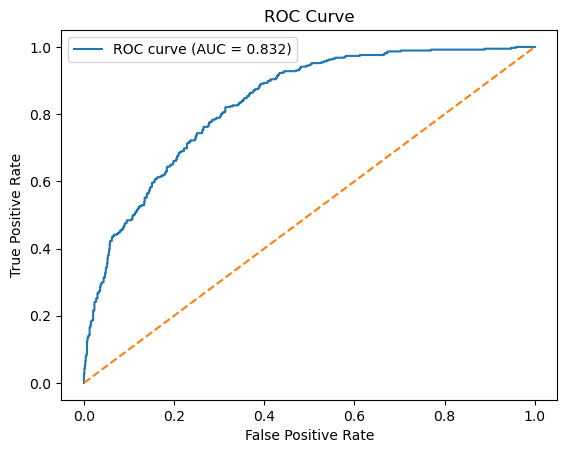

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.3f)" % auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [52]:
features = ['MonthlyCharges', 'TotalCharges', 'tenure']
X_cluster = df[features]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [54]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

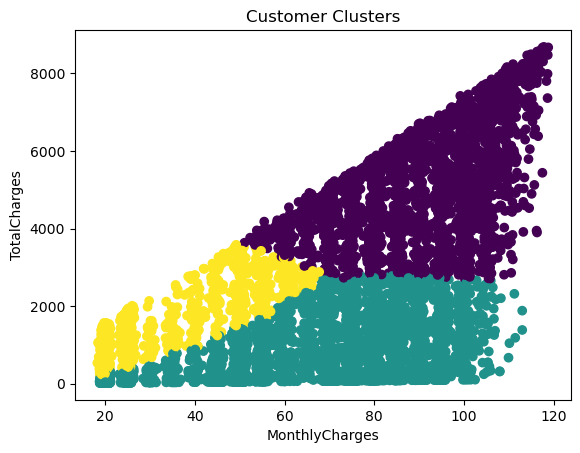

In [55]:
plt.scatter(df['MonthlyCharges'], df['TotalCharges'], c=df['Cluster'])
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")
plt.title("Customer Clusters")
plt.show()

In [56]:
distances = kmeans.transform(X_scaled)
min_dist = distances.min(axis=1)

threshold = np.percentile(min_dist, 95)
df['Anomaly'] = min_dist > threshold

2026-02-13 13:57:02.084 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:57:03.258 
  command:

    streamlit run C:\Users\Admin\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-02-13 13:57:03.266 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:57:03.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:57:03.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:57:03.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:57:03.315 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-13 13:57:03.388 Thread 'MainThread': mi

DeltaGenerator()

In [64]:
import re
import pandas as pd

# Sample logs
logs = [
    "2026-02-01 10:32:15 | USER123 | CALL_DROP | Tower_45 | Duration: 35s",
    "2026-02-01 10:35:20 | USER456 | SUCCESS_CALL | Tower_12 | Duration: 120s"
]

pattern = r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) \| (\w+) \| (\w+) \| (\w+) \| Duration: (\d+)s'

parsed_data = []

for log in logs:
    match = re.match(pattern, log)
    if match:
        parsed_data.append(match.groups())

df_logs = pd.DataFrame(parsed_data, columns=[
    "Timestamp", "UserID", "CallStatus", "TowerID", "Duration"
])

df_logs["Duration"] = df_logs["Duration"].astype(int)

df_logs.head()

,Timestamp,UserID,CallStatus,TowerID,Duration
0,2026-02-01 10:32:15,USER123,CALL_DROP,Tower_45,35
1,2026-02-01 10:35:20,USER456,SUCCESS_CALL,Tower_12,120


In [65]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Cluster             0
Anomaly             0
dtype: int64

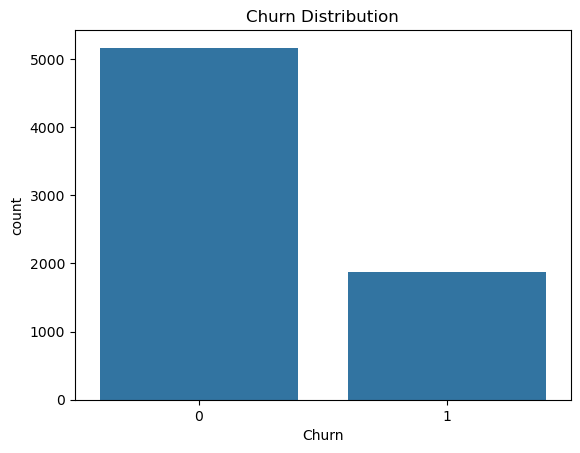

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

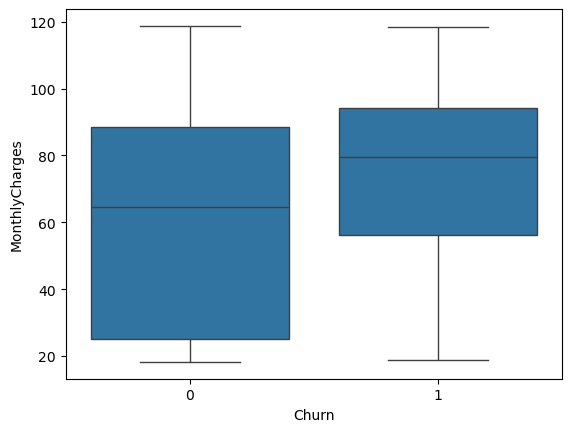

In [67]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

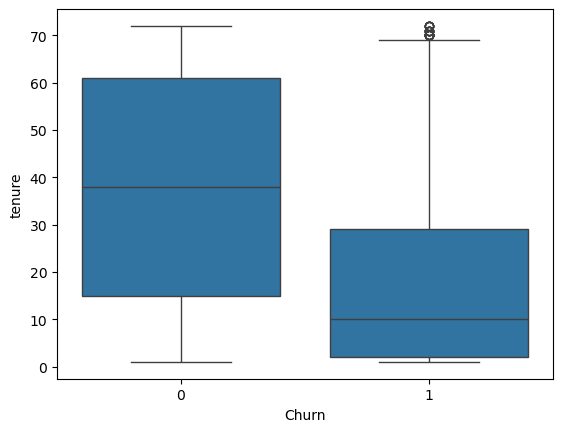

In [68]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

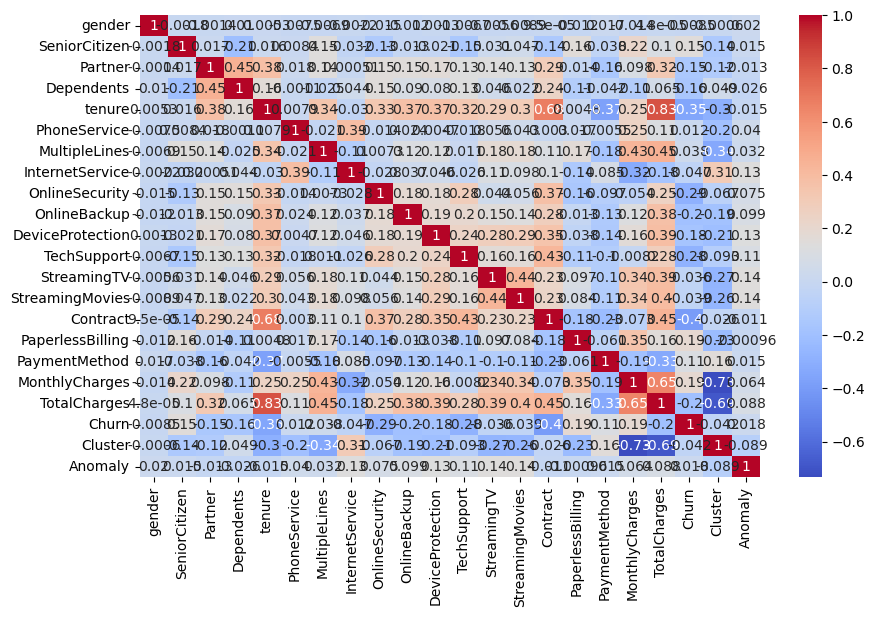

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [70]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Cluster             0
Anomaly             0
dtype: int64

In [78]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [79]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [80]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.940557,0.872582,0.789249,0.905859,...,0.796359,0.984926,0.992890,0.688567,0.592719,1.573237,64.798208,2283.300441,0.265785,0.894198
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.948627,0.737271,0.859962,0.880394,...,0.861674,0.885285,0.885385,0.832934,0.491363,1.067504,30.085974,2266.771362,0.441782,0.716278
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.587500,401.450000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.350000,1397.475000,0.000000,1.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.862500,3794.737500,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000,2.000000


In [81]:
df.isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Cluster             0
Anomaly             0
dtype: int64

In [83]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [84]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Cluster             0
Anomaly             0
dtype: int64

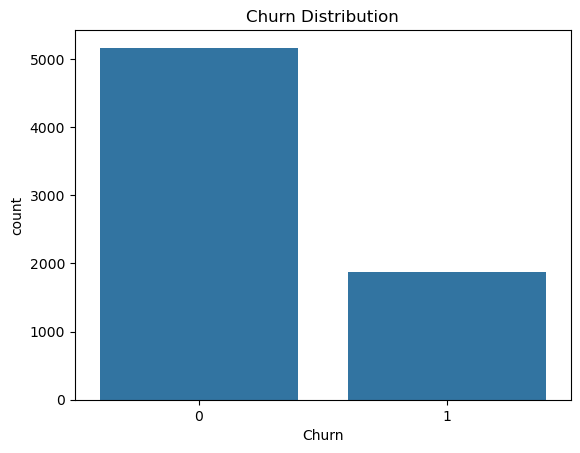

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

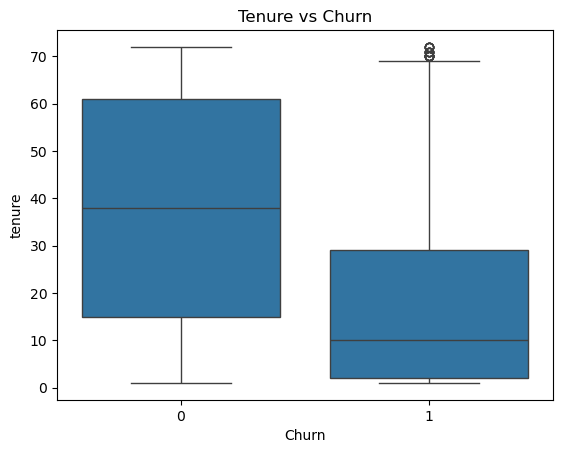

In [86]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

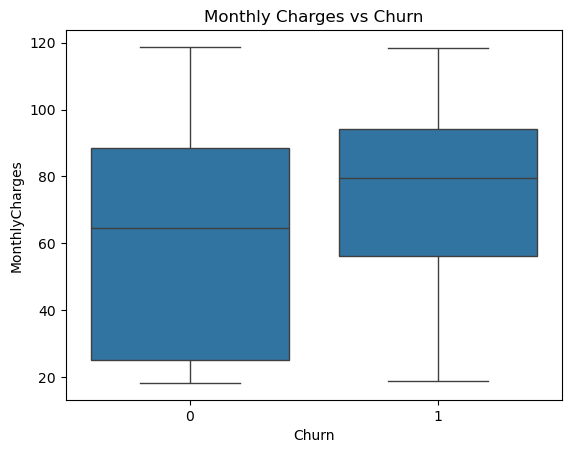

In [87]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

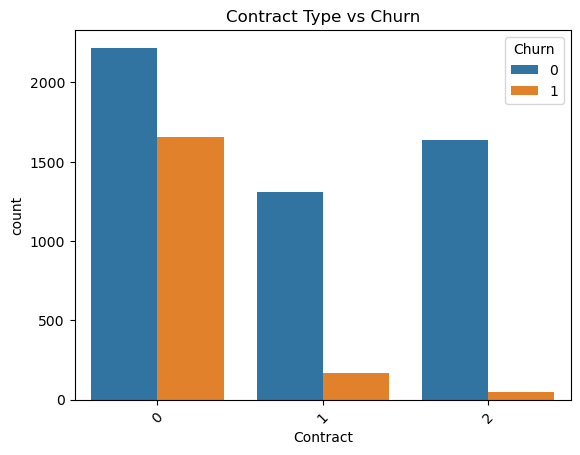

In [88]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

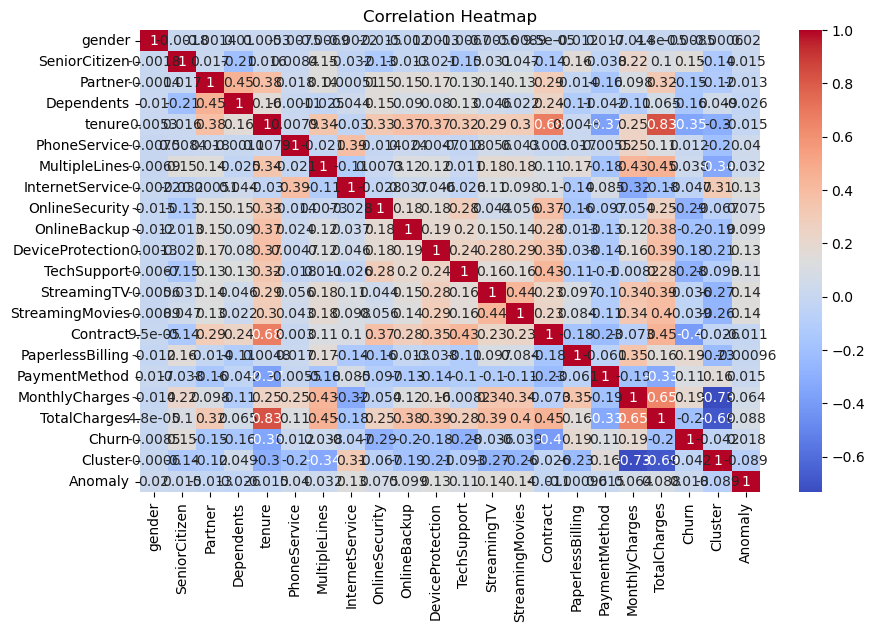

In [89]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 📊 Phase 1: Key Business Insights

### 1️⃣ Churn Distribution
- A significant portion of customers are churning.
- The dataset shows imbalance between churned and retained customers.

### 2️⃣ Tenure Impact
- Customers with low tenure (new customers) have higher churn rates.
- Long-term customers are more stable and loyal.

### 3️⃣ Monthly Charges Impact
- Higher monthly charges increase the probability of churn.
- Price-sensitive customers are more likely to leave.

### 4️⃣ Contract Type Effect
- Month-to-month contracts show the highest churn rate.
- One-year and two-year contracts reduce churn significantly.

### 5️⃣ Correlation Insights
- TotalCharges strongly correlate with tenure.
- MonthlyCharges influence churn behavior.
- Long-term contracts improve retention.

---

## 📌 Business Recommendation

- Offer long-term contract incentives.
- Provide discounts for high monthly charge customers.
- Target new customers with retention campaigns.

In [91]:
import re
import pandas as pd

logs = [
    "2026-02-01 10:32:15 | USER123 | CALL_DROP | Tower_45 | Duration: 35s",
    "2026-02-01 10:35:20 | USER456 | SUCCESS_CALL | Tower_12 | Duration: 120s"
]

pattern = r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) \| (\w+) \| (\w+) \| (\w+) \| Duration: (\d+)s'

parsed_data = []

for log in logs:
    match = re.match(pattern, log)
    if match:
        parsed_data.append(match.groups())

df_logs = pd.DataFrame(parsed_data, columns=[
    "Timestamp", "UserID", "CallStatus", "TowerID", "Duration"
])

df_logs

,Timestamp,UserID,CallStatus,TowerID,Duration
0,2026-02-01 10:32:15,USER123,CALL_DROP,Tower_45,35
1,2026-02-01 10:35:20,USER456,SUCCESS_CALL,Tower_12,120


In [92]:
df.select_dtypes(include=['int64','float64']).head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:
corr_matrix = df.corr(numeric_only=True)

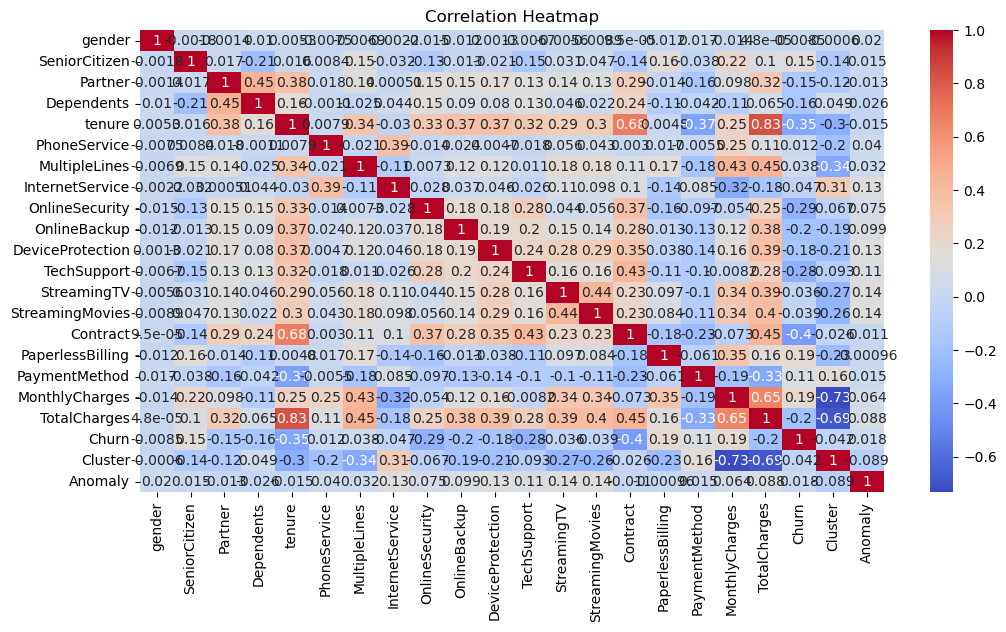

In [95]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insight:
- TotalCharges strongly correlates with tenure.
- MonthlyCharges has moderate influence on churn.
- No extremely high multicollinearity observed.